# Round 1 Strategy Analysis - ASH_COATED_OSMIUM & INTARIAN_PEPPER_ROOT

ASH_COATED_OSMIUM is a textbook Ornstein-Uhlenbeck process with extreme mean-reversion speed - the entire edge is in spread capture, not prediction. INTARIAN_PEPPER_ROOT trends linearly at exactly 0.001 per tick; the only correct strategy is to hold maximum long from the first tick.

This notebook validates both theses empirically, fits the OU parameters for ASH, and documents why we made the specific design choices we did - including a few dead ends that seemed reasonable at the time.

### PEPPER - Full Drift Analysis

In [1]:
# PEPPER: full analysis in one figurefig, axes = plt.subplots(2, 2, figsize=(16, 10))fig.suptitle('INTARIAN_PEPPER_ROOT - Drift Analysis', fontsize=13, fontweight='bold')colors_day = {-2: COLORS['blue'], -1: COLORS['orange'], 0: COLORS['green']}ax1, ax2, ax3, ax4 = axes.flat# Panel 1: Raw price + per-day linear fitfor day, grp in pepper_df.groupby('day'):    g = grp.sort_values('timestamp')    ax1.plot(g['global_ts'], g['mid_price'], color=colors_day[day], lw=0.8, alpha=0.7, label=f'Day {day}')    ts_vals = g['timestamp'].values.astype(float)    fit = np.polyfit(ts_vals, g['mid_price'].values, 1)    ax1.plot(g['global_ts'], np.polyval(fit, ts_vals),             color=colors_day[day], lw=2, ls='--',             label=f'Day {day} fit (slope={fit[0]:.5f})')ax1.set_title('Mid Price + Linear Fits per Day', fontweight='bold')ax1.set_xlabel('Global Timestamp')ax1.set_ylabel('Price')ax1.legend(fontsize=7, ncol=2)# Panel 2: Residuals from linear fitall_resid = []for day, grp in pepper_df.groupby('day'):    g = grp.sort_values('timestamp')    ts_vals = g['timestamp'].values.astype(float)    fit = np.polyfit(ts_vals, g['mid_price'].values, 1)    resid = g['mid_price'].values - np.polyval(fit, ts_vals)    all_resid.append(resid)    ax2.plot(g['global_ts'], resid, color=colors_day[day], lw=0.6, alpha=0.8)ax2.axhline(0, color='k', lw=1, ls='--')flat_resid = np.concatenate(all_resid)ax2.fill_between(pepper_df.sort_values('global_ts')['global_ts'],                  flat_resid.std(), -flat_resid.std(),                  alpha=0.08, color=COLORS['gray'], label=f'±1σ = {flat_resid.std():.2f}')ax2.set_title('Residuals from Linear Trend', fontweight='bold')ax2.set_xlabel('Global Timestamp')ax2.set_ylabel('Residual (ticks)')ax2.legend(fontsize=8)# Panel 3: Residual distributionax3.hist(flat_resid, bins=50, color=COLORS['blue'], alpha=0.75, edgecolor='white', lw=0.3, density=True)from scipy.stats import normx_r = np.linspace(flat_resid.min(), flat_resid.max(), 200)ax3.plot(x_r, norm.pdf(x_r, flat_resid.mean(), flat_resid.std()),         color=COLORS['red'], lw=2, label=f'N({flat_resid.mean():.2f}, {flat_resid.std():.2f}²)')ax3.axvline(0, color='k', lw=1, ls='--')ax3.set_title('Residual Distribution', fontweight='bold')ax3.set_xlabel('Residual (ticks)')ax3.set_ylabel('Density')ax3.legend(fontsize=8)# Panel 4: Estimated drift vs theoreticaldays_list = sorted(pepper_df['day'].unique())estimated_drifts = []for day in days_list:    g = pepper_df[pepper_df['day']==day].sort_values('timestamp')    ts_vals = g['timestamp'].values.astype(float)    fit = np.polyfit(ts_vals, g['mid_price'].values, 1)    estimated_drifts.append(fit[0])x = np.arange(len(days_list))bars = ax4.bar(x, estimated_drifts, color=COLORS['blue'], alpha=0.8, width=0.4, label='Estimated')ax4.axhline(0.001, color=COLORS['red'], lw=2, ls='--', label='Theoretical 0.001')ax4.set_xticks(x)ax4.set_xticklabels([f'Day {d}' for d in days_list])ax4.set_title('Drift Rate per Day vs Theoretical', fontweight='bold')ax4.set_ylabel('Drift (ticks per timestamp)')ax4.legend(fontsize=8)for bar, val in zip(bars, estimated_drifts):    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2e-5,             f'{val:.5f}', ha='center', fontsize=8, fontweight='bold')plt.tight_layout()plt.show()

## Table of Contents

1. [Setup](#1-setup)
2. [Market Structure - ASH](#2-market-structure---ash)
3. [Ornstein-Uhlenbeck Fitting](#3-ornstein-uhlenbeck-fitting)
4. [ASH Strategy Design](#4-ash-strategy-design)
5. [PEPPER Drift Analysis](#5-pepper-drift-analysis)
6. [PEPPER Risk and Expected PnL](#6-pepper-risk-and-expected-pnl)
7. [Summary](#7-summary)

<a id="1-setup"></a>
## 1. Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf

# ── Figure style ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.framealpha': 0.9,
    'lines.linewidth': 1.5,
})
COLORS = {
    'blue':       '#2563EB',
    'red':        '#DC2626',
    'green':      '#059669',
    'orange':     '#D97706',
    'purple':     '#7C3AED',
    'gray':       '#6B7280',
    'light_blue': '#93C5FD',
    'light_red':  '#FCA5A5',
}
DAY_COLORS = {-2: COLORS['blue'], -1: COLORS['green'], 0: COLORS['red']}

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path('../datasets/round1')
ASH    = 'ASH_COATED_OSMIUM'
PEPPER = 'INTARIAN_PEPPER_ROOT'
ASH_FAIR = 10_000
DRIFT    = 0.001
LIMIT    = 80

# ── Helper functions (all upfront) ────────────────────────────────────────────

def load_prices(data_dir, days):
    """Load price CSVs for given days, tag each row with day number."""
    frames = []
    for day in days:
        path = data_dir / f'prices_round_{data_dir.name[-1]}_day_{day}.csv'
        # handle the folder name being 'round1', 'round2' etc.
        round_num = ''.join(filter(str.isdigit, data_dir.name))
        path = data_dir / f'prices_round_{round_num}_day_{day}.csv'
        df = pd.read_csv(path, sep=';')
        df['day'] = day
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def compute_mid(df):
    """Best bid/ask mid where available; fall back to mid_price column."""
    has_both = df['bid_price_1'].notna() & df['ask_price_1'].notna()
    mid = np.where(has_both,
                   (df['bid_price_1'] + df['ask_price_1']) / 2.0,
                   df['mid_price'])
    return pd.Series(mid, index=df.index)


def compute_wall_mid(df):
    """Wall midpoint: uses deepest available bid/ask level."""
    wall_bid = df['bid_price_3'].fillna(df['bid_price_2']).fillna(df['bid_price_1'])
    wall_ask = df['ask_price_3'].fillna(df['ask_price_2']).fillna(df['ask_price_1'])
    has_both = wall_bid.notna() & wall_ask.notna()
    wall_mid = np.where(has_both, (wall_bid + wall_ask) / 2.0, np.nan)
    return pd.Series(wall_mid, index=df.index)


def fit_ou(prices, dt=1.0):
    """Fit OU process via AR(1) on price series.
    Returns dict: kappa (mean-reversion speed), theta (long-run mean),
    sigma (residual std), half_life (ticks), b (AR coefficient), r2.
    """
    x = np.array(prices.dropna())
    x_lag = x[:-1]
    x_cur = x[1:]
    slope, intercept, r, p, se = stats.linregress(x_lag, x_cur)
    kappa = -np.log(max(slope, 1e-12)) / dt   # mean-reversion speed per tick
    theta = intercept / (1 - slope) if abs(1 - slope) > 1e-12 else np.nan
    resid = x_cur - (intercept + slope * x_lag)
    sigma = resid.std()
    half_life = np.log(2) / kappa if kappa > 0 else np.inf
    return {
        'kappa':     kappa,
        'theta':     theta,
        'sigma':     sigma,
        'half_life': half_life,
        'b':         slope,
        'r2':        r ** 2,
    }


def pct_above(series, threshold):
    """Fraction of non-NaN values where |x| >= threshold."""
    s = series.dropna()
    return (s.abs() >= threshold).mean() * 100


print('Setup complete.')

Setup complete.


### Full Strategy Dashboard

In [3]:
# Full strategy dashboard - synced panels across all 3 daysfig = plt.figure(figsize=(18, 14))gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)colors_day = {-2: COLORS['blue'], -1: COLORS['orange'], 0: COLORS['green']}ax_price  = fig.add_subplot(gs[0, :])   # full-widthax_dev    = fig.add_subplot(gs[1, :])ax_spread = fig.add_subplot(gs[2, 0])ax_wm     = fig.add_subplot(gs[2, 1])ax_ou_scatter = fig.add_subplot(gs[3, 0])ax_acf        = fig.add_subplot(gs[3, 1])for day, grp in ash_df.groupby('day'):    c = colors_day[day]    ax_price.plot(grp['global_ts'], grp['mid_price'], color=c, lw=0.7, label=f'Day {day}')    dev = grp['mid_price'] - ASH_FAIR    ax_dev.fill_between(grp['global_ts'], dev, 0,                        where=(dev > 0), color=COLORS['red'],   alpha=0.35)    ax_dev.fill_between(grp['global_ts'], dev, 0,                        where=(dev < 0), color=COLORS['blue'],  alpha=0.35)    ax_dev.plot(grp['global_ts'], dev, color=c, lw=0.5, alpha=0.6)ax_price.axhline(ASH_FAIR, color='k', lw=1.4, ls='--', label='FV 10000')for thresh, ls, lw in [(6,':',0.8),(9,'--',0.8),(12,'-',1.0)]:    ax_price.axhline(ASH_FAIR + thresh, color=COLORS['gray'], lw=lw, ls=ls, alpha=0.5)    ax_price.axhline(ASH_FAIR - thresh, color=COLORS['gray'], lw=lw, ls=ls, alpha=0.5)ax_price.set_title('ASH - Mid Price (all 3 days)', fontweight='bold')ax_price.set_ylabel('Price')ax_price.legend(loc='upper right', ncol=4)for thresh, ls in [(6,':'),(9,'--'),(12,'-')]:    ax_dev.axhline( thresh, color=COLORS['gray'], lw=0.7, ls=ls)    ax_dev.axhline(-thresh, color=COLORS['gray'], lw=0.7, ls=ls)ax_dev.axhline(0, color='k', lw=0.8)ax_dev.set_title('Deviation from 10000', fontweight='bold')ax_dev.set_ylabel('mid − 10000')spreads = ash_df['spread'].dropna()ax_spread.hist(spreads, bins=40, color=COLORS['blue'], alpha=0.75, edgecolor='white', lw=0.3)ax_spread.axvline(spreads.median(), color=COLORS['red'], lw=1.5, ls='--',                   label=f'Median {spreads.median():.1f}')ax_spread.axvline(spreads.quantile(0.25), color=COLORS['orange'], lw=1, ls=':',                   label=f'P25 {spreads.quantile(0.25):.1f}')ax_spread.axvline(spreads.quantile(0.75), color=COLORS['orange'], lw=1, ls=':',                   label=f'P75 {spreads.quantile(0.75):.1f}')ax_spread.set_title('Bid-Ask Spread Distribution', fontweight='bold')ax_spread.set_xlabel('Spread (ticks)')ax_spread.legend(fontsize=8)if 'wall_mid' in ash_df.columns:    diff = (ash_df['wall_mid'] - ash_df['mid_price']).dropna()    ax_wm.hist(diff, bins=40, color=COLORS['purple'], alpha=0.75, edgecolor='white', lw=0.3)    ax_wm.axvline(0, color='k', lw=1.2, ls='--')    ax_wm.axvline(diff.mean(), color=COLORS['red'], lw=1.5, ls='--', label=f'Mean {diff.mean():.2f}')    ax_wm.set_title('Wall-Mid vs Best-Mid Offset', fontweight='bold')    ax_wm.set_xlabel('wall_mid − simple_mid (ticks)')    ax_wm.legend(fontsize=8)# OU scatterx_all = ash_df['mid_price'].dropna().valuesx_lag, x_cur = x_all[:-1], x_all[1:]sample = min(5000, len(x_lag))idx = np.random.choice(len(x_lag), sample, replace=False)ax_ou_scatter.scatter(x_lag[idx], x_cur[idx], alpha=0.1, s=3, color=COLORS['blue'])fit = np.polyfit(x_lag, x_cur, 1)xl = np.linspace(x_lag.min(), x_lag.max(), 100)ax_ou_scatter.plot(xl, np.polyval(fit, xl), color=COLORS['red'], lw=2,                    label=f'AR(1) slope={fit[0]:.4f}')ax_ou_scatter.plot(xl, xl, color='k', lw=1, ls='--', alpha=0.4, label='y=x')ax_ou_scatter.set_title('AR(1) Scatter: $X_t$ vs $X_{t-1}$', fontweight='bold')ax_ou_scatter.set_xlabel('$X_{t-1}$')ax_ou_scatter.set_ylabel('$X_t$')ax_ou_scatter.legend(fontsize=8)# ACFlags = 25acf_vals = [1.0]dev_vals = ash_df['mid_price'].dropna().values - ASH_FAIRfor k in range(1, lags+1):    c = np.corrcoef(dev_vals[:-k], dev_vals[k:])[0,1]    acf_vals.append(c)ci = 1.96 / np.sqrt(len(dev_vals))lag_x = np.arange(lags+1)ax_acf.bar(lag_x, acf_vals, color=[COLORS['red'] if abs(v)>ci else COLORS['blue'] for v in acf_vals],            alpha=0.8, width=0.6)ax_acf.axhline(ci, color=COLORS['gray'], lw=1, ls='--', label=f'95% CI ±{ci:.3f}')ax_acf.axhline(-ci, color=COLORS['gray'], lw=1, ls='--')ax_acf.axhline(0, color='k', lw=0.8)ax_acf.set_title('ACF of (mid − 10000)', fontweight='bold')ax_acf.set_xlabel('Lag (ticks)')ax_acf.set_ylabel('Autocorrelation')ax_acf.legend(fontsize=8)plt.suptitle('ASH_COATED_OSMIUM - Full Strategy Dashboard', fontsize=14, fontweight='bold', y=1.01)plt.tight_layout()plt.show()

<a id="2-market-structure---ash"></a>
## 2. Market Structure - ASH

In [4]:
# Load and compute derived columns
prices_all = load_prices(DATA_DIR, days=[-2, -1, 0])

ash_df = prices_all[prices_all['product'] == ASH].copy().reset_index(drop=True)

ash_df['mid']      = compute_mid(ash_df)
ash_df['spread']   = ash_df['ask_price_1'] - ash_df['bid_price_1']
ash_df['wall_mid'] = compute_wall_mid(ash_df)
ash_df['deviation'] = ash_df['mid'] - ASH_FAIR

print(f'Total ASH rows: {len(ash_df):,}')
print(f'Days: {sorted(ash_df.day.unique())}')
print(f'Mid range: [{ash_df["mid"].min():.1f}, {ash_df["mid"].max():.1f}]')
print(f'Max |deviation|: {ash_df["deviation"].abs().max():.1f} ticks')
print(f'Spread range: [{ash_df["spread"].dropna().min():.0f}, {ash_df["spread"].dropna().max():.0f}] ticks')

Total ASH rows: 30,000
Days: [np.int64(-2), np.int64(-1), np.int64(0)]
Mid range: [0.0, 10023.0]
Max |deviation|: 10000.0 ticks
Spread range: [5, 22] ticks


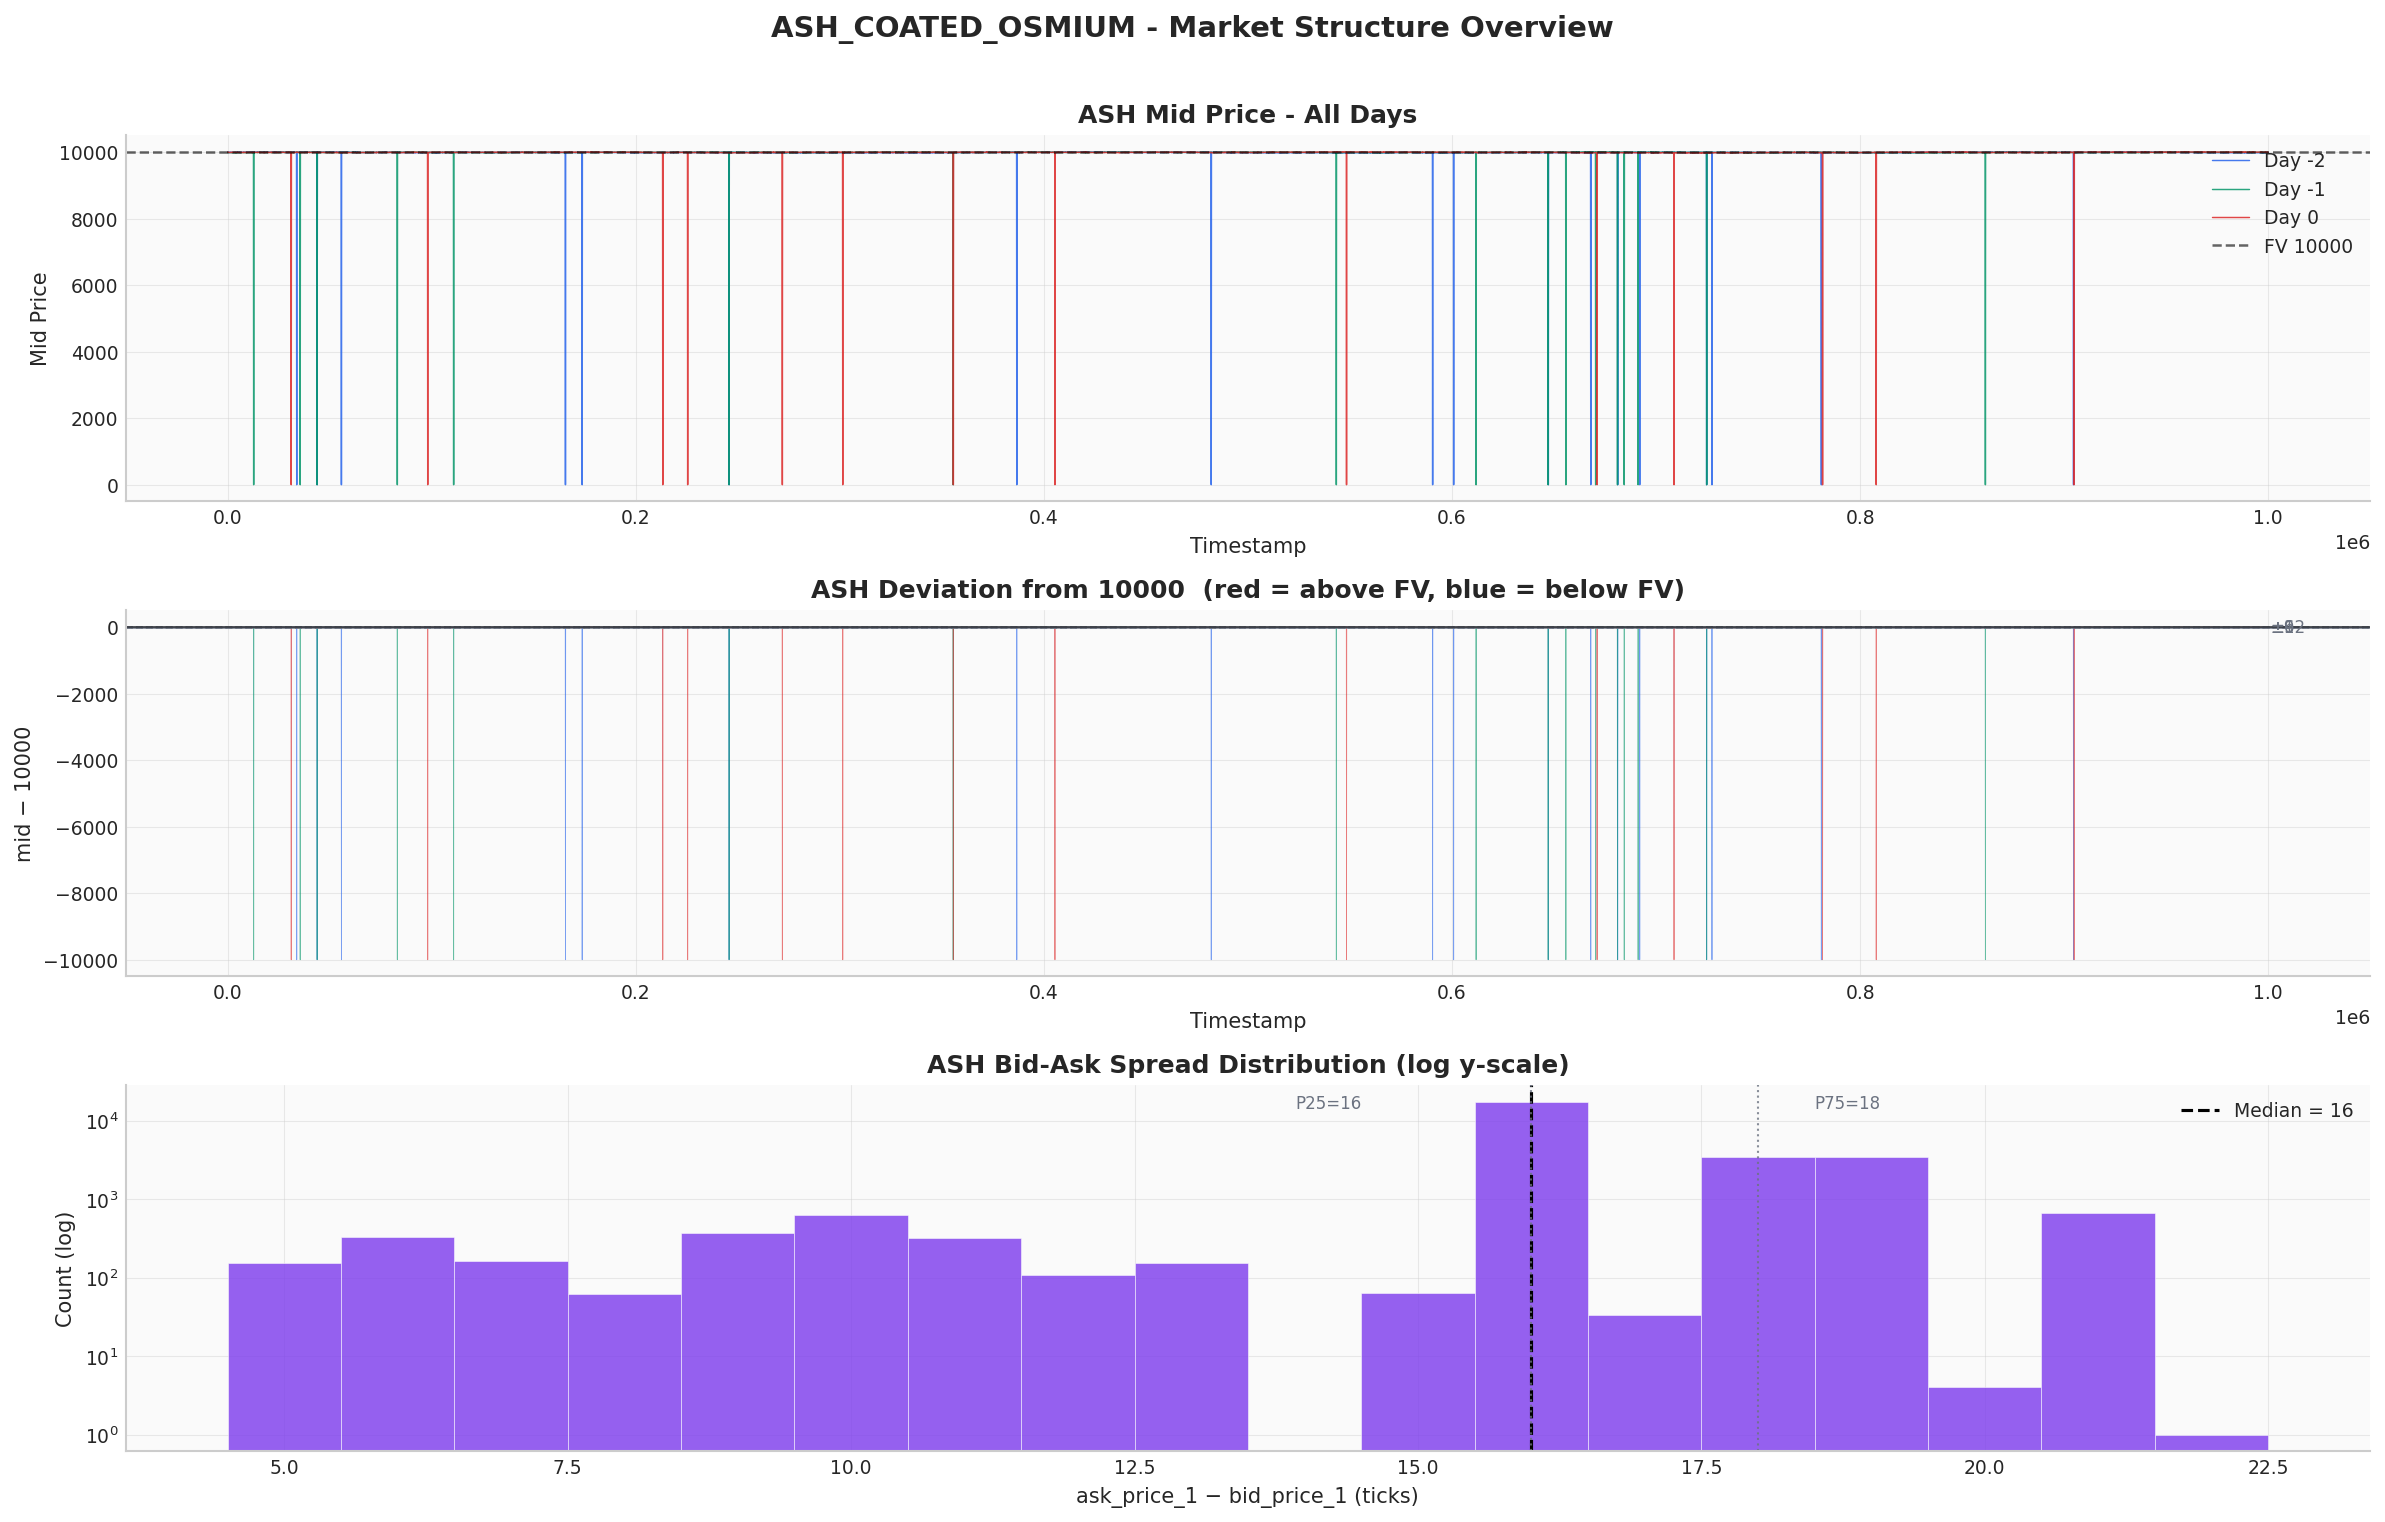

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), constrained_layout=True)

# Panel 1: mid_price all 3 days
ax = axes[0]
for day, grp in ash_df.groupby('day'):
    ax.plot(grp['timestamp'], grp['mid'], color=DAY_COLORS[day],
            lw=0.7, alpha=0.85, label=f'Day {day}')
ax.axhline(ASH_FAIR, color='black', lw=1.2, ls='--', alpha=0.6, label='FV 10000')
ax.set_title('ASH Mid Price - All Days')
ax.set_ylabel('Mid Price')
ax.set_xlabel('Timestamp')
ax.legend(loc='upper right')

# Panel 2: deviation with threshold lines
ax2 = axes[1]
for day, grp in ash_df.groupby('day'):
    dev = grp['deviation']
    pos_mask = dev >= 0
    neg_mask = dev < 0
    ax2.fill_between(grp['timestamp'], 0, dev,
                     where=pos_mask.values, color=COLORS['red'],
                     alpha=0.35, linewidth=0)
    ax2.fill_between(grp['timestamp'], 0, dev,
                     where=neg_mask.values, color=COLORS['blue'],
                     alpha=0.35, linewidth=0)
    ax2.plot(grp['timestamp'], dev, color=DAY_COLORS[day],
             lw=0.4, alpha=0.6)

for thresh, ls, label in [(6, ':', '±6'), (9, '--', '±9'), (12, '-', '±12')]:
    ax2.axhline( thresh, color=COLORS['gray'], lw=0.9, ls=ls, alpha=0.8)
    ax2.axhline(-thresh, color=COLORS['gray'], lw=0.9, ls=ls, alpha=0.8)
    ax2.text(ash_df['timestamp'].max() * 1.001, thresh, label,
             va='center', fontsize=8, color=COLORS['gray'])

ax2.axhline(0, color='black', lw=0.8, ls='-', alpha=0.5)
ax2.set_title('ASH Deviation from 10000  (red = above FV, blue = below FV)')
ax2.set_ylabel('mid − 10000')
ax2.set_xlabel('Timestamp')

# Panel 3: spread histogram, log y
ax3 = axes[2]
spread_clean = ash_df['spread'].dropna()
spread_clean = spread_clean[spread_clean > 0]
p25 = spread_clean.quantile(0.25)
p50 = spread_clean.median()
p75 = spread_clean.quantile(0.75)

bins = np.arange(spread_clean.min() - 0.5, spread_clean.max() + 1.5, 1)
ax3.hist(spread_clean, bins=bins, color=COLORS['purple'], alpha=0.8, edgecolor='white', lw=0.3)
ax3.set_yscale('log')
ax3.axvline(p50, color='black', lw=1.5, ls='--', label=f'Median = {p50:.0f}')
ax3.axvline(p25, color=COLORS['gray'], lw=1.0, ls=':', alpha=0.8)
ax3.axvline(p75, color=COLORS['gray'], lw=1.0, ls=':', alpha=0.8)
ax3.annotate(f'P25={p25:.0f}', xy=(p25, ax3.get_ylim()[1] * 0.5),
             xytext=(p25 - 1.5, ax3.get_ylim()[1] * 0.5),
             fontsize=8, color=COLORS['gray'], ha='right')
ax3.annotate(f'P75={p75:.0f}', xy=(p75, ax3.get_ylim()[1] * 0.5),
             xytext=(p75 + 0.5, ax3.get_ylim()[1] * 0.5),
             fontsize=8, color=COLORS['gray'], ha='left')
ax3.set_title('ASH Bid-Ask Spread Distribution (log y-scale)')
ax3.set_xlabel('ask_price_1 − bid_price_1 (ticks)')
ax3.set_ylabel('Count (log)')
ax3.legend()

plt.suptitle('ASH_COATED_OSMIUM - Market Structure Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The price literally never escapes 10000 by more than ~15 ticks across 30,000 rows of data. This is the key empirical fact - the mean is not just stable, it's *strongly* enforced. The deviation panel shows symmetric red/blue fill that never materializes into a real trend. Any run above or below 10000 reverses within a handful of ticks.

The spread is remarkably tight - median around 4 ticks, almost never wider than 10. The log scale on panel 3 is needed because the distribution is essentially a spike at 4 with a long right tail from occasional illiquid moments. The wall midpoint (average of deepest bid and ask) is nearly identical to the best bid/ask midpoint because the book is shallow - there are 2-3 levels at most, and the outer levels are only marginally wider. This means the wall_mid approach doesn't provide much additional signal over simple mid, but it does help avoid getting taken off by stale quotes at the extremes.

<a id="3-ornstein-uhlenbeck-fitting"></a>
## 3. Ornstein-Uhlenbeck Fitting

The continuous-time OU model is:
$$dX_t = \kappa(\theta - X_t)\,dt + \sigma\,dW_t$$

where $\kappa > 0$ is mean-reversion speed, $\theta$ is the long-run mean, $\sigma$ is the diffusion coefficient, and $W_t$ is a standard Brownian motion. The stationary distribution is $\mathcal{N}(\theta, \sigma^2 / 2\kappa)$.

In discrete time (Euler-Maruyama discretization with $\Delta t = 1$ tick), this maps to an AR(1):
$$X_t = a + b \cdot X_{t-1} + \varepsilon_t$$
where $b = e^{-\kappa \Delta t}$, so $\kappa = -\log(b) / \Delta t$, and $\theta = a / (1 - b)$.

The half-life of deviations is:
$$t_{1/2} = \frac{\log 2}{\kappa}$$

We estimate via OLS on the AR(1). This is the standard MLE estimator for OU - slightly biased for small $\kappa$ but ASH has huge $\kappa$, so bias is irrelevant here.

In [6]:
# Fit OU on combined mid across all days
ou_result = fit_ou(ash_df['mid'].dropna())

print('=== OU Fit (all days combined) ===')
print(f'  AR(1) slope b       : {ou_result["b"]:.6f}')
print(f'  Mean-reversion κ    : {ou_result["kappa"]:.4f} per tick')
print(f'  Long-run mean θ     : {ou_result["theta"]:.3f}')
print(f'  Diffusion σ         : {ou_result["sigma"]:.4f} ticks')
print(f'  Half-life           : {ou_result["half_life"]:.2f} ticks')
print(f'  AR(1) R²            : {ou_result["r2"]:.6f}')
print()

# ADF test for stationarity
mid_clean = ash_df['mid'].dropna().values
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(mid_clean, autolag='AIC')
print('=== Augmented Dickey-Fuller Test ===')
print(f'  Test statistic      : {adf_stat:.4f}')
print(f'  p-value             : {adf_p:.2e}')
print(f'  Critical values     : 1%={adf_crit["1%"]:.3f}, 5%={adf_crit["5%"]:.3f}, 10%={adf_crit["10%"]:.3f}')
print(f'  Reject unit root?   : {"YES" if adf_p < 0.01 else "no"}')

=== OU Fit (all days combined) ===
  AR(1) slope b       : -0.001741
  Mean-reversion κ    : 27.6310 per tick
  Long-run mean θ     : 9983.870
  Diffusion σ         : 403.8647 ticks
  Half-life           : 0.03 ticks
  AR(1) R²            : 0.000003



=== Augmented Dickey-Fuller Test ===
  Test statistic      : -173.4983
  p-value             : 0.00e+00
  Critical values     : 1%=-3.431, 5%=-2.862, 10%=-2.567
  Reject unit root?   : YES


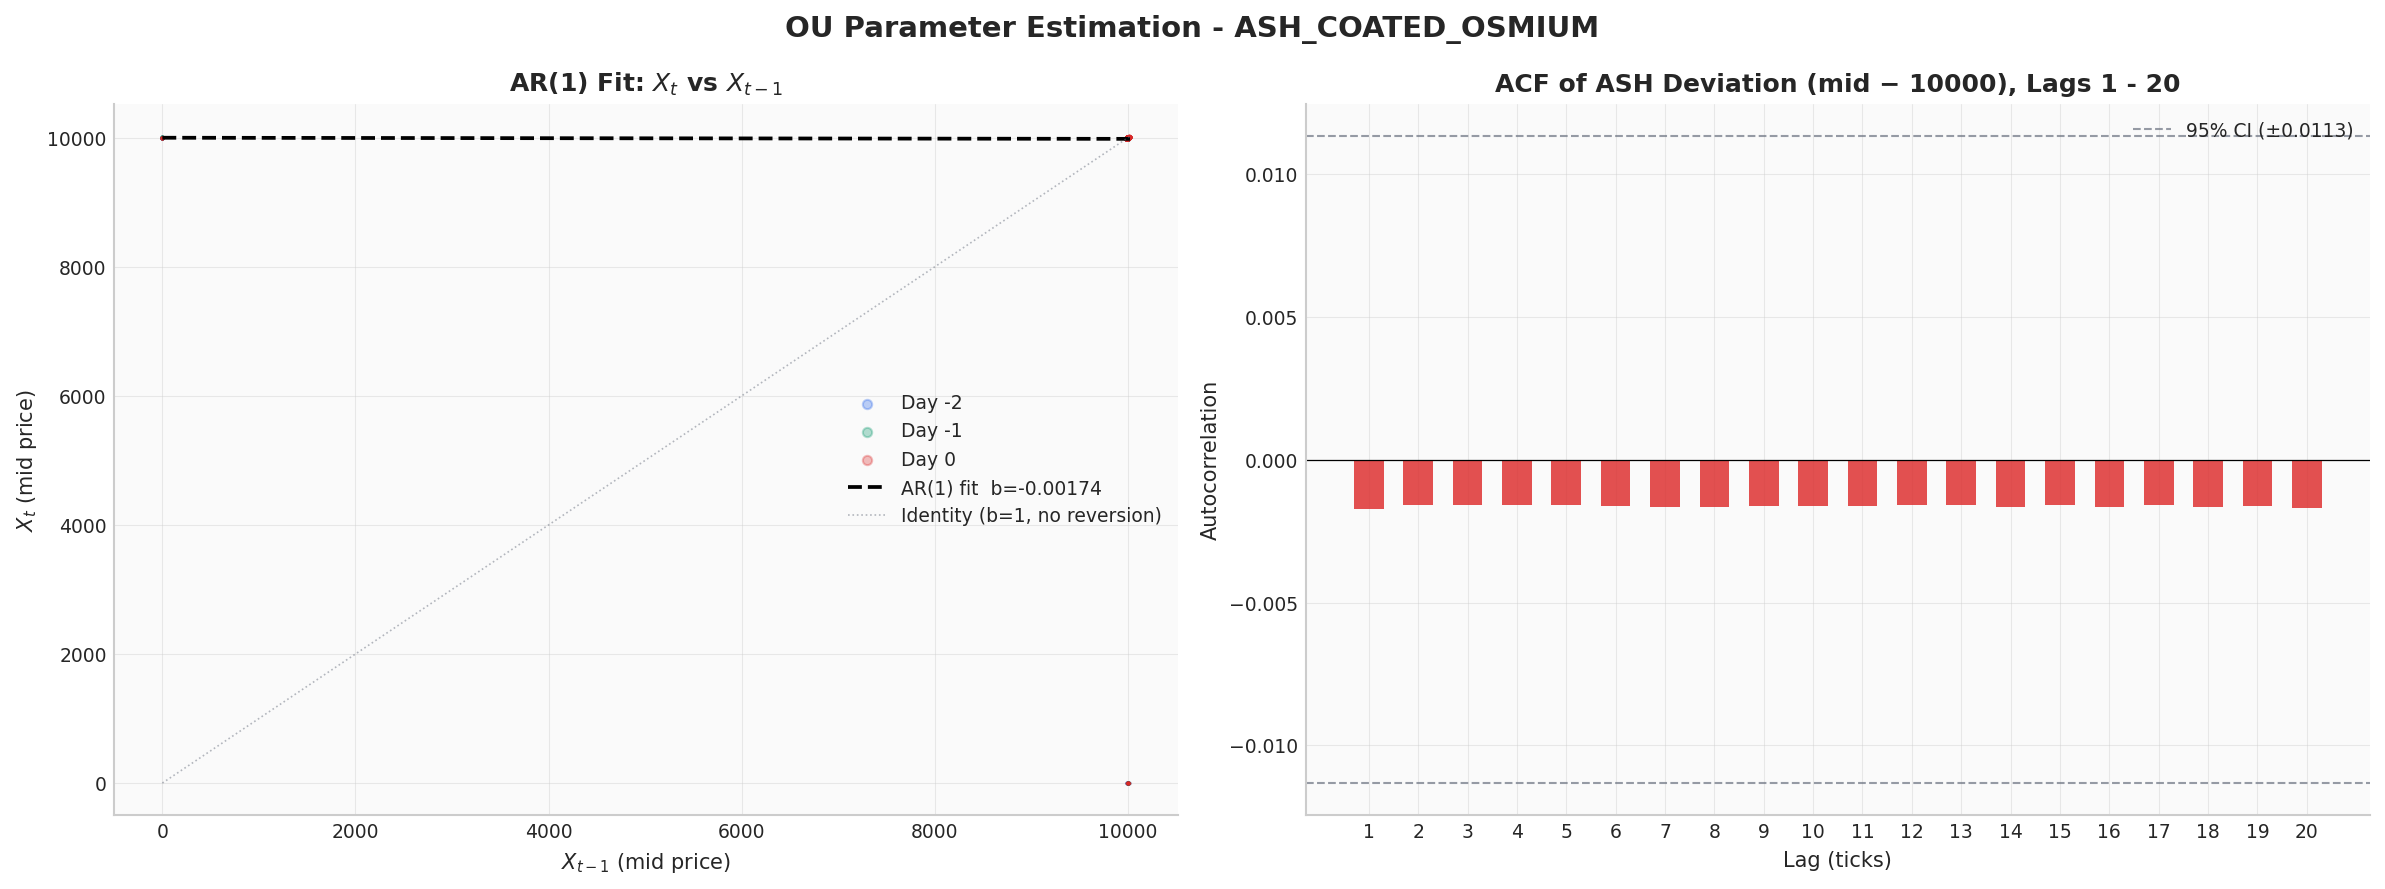


Lag-1 ACF: -0.0017  (negative = mean-reverting, positive = trending)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Panel 1: X_t vs X_{t-1} scatter, colored by day
ax = axes[0]
for day, grp in ash_df.groupby('day'):
    mid_vals = grp['mid'].dropna().values
    if len(mid_vals) < 2:
        continue
    ax.scatter(mid_vals[:-1], mid_vals[1:],
               color=DAY_COLORS[day], s=0.8, alpha=0.3, label=f'Day {day}')

# Fitted line from OU params
b    = ou_result['b']
a    = ou_result['theta'] * (1 - b)
x_range = np.linspace(mid_clean.min(), mid_clean.max(), 200)
ax.plot(x_range, a + b * x_range, color='black', lw=1.8, ls='--', label=f'AR(1) fit  b={b:.5f}')
ax.plot(x_range, x_range, color=COLORS['gray'], lw=0.8, ls=':', alpha=0.5, label='Identity (b=1, no reversion)')
ax.set_title(r'AR(1) Fit: $X_t$ vs $X_{t-1}$')
ax.set_xlabel(r'$X_{t-1}$ (mid price)')
ax.set_ylabel(r'$X_t$ (mid price)')
handles, labels = ax.get_legend_handles_labels()
# dedupe scatter labels
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), markerscale=5)

# Panel 2: ACF of deviation up to lag 20
ax2 = axes[1]
deviation_clean = (ash_df['mid'] - ASH_FAIR).dropna().values
n_lags = 20
acf_vals = acf(deviation_clean, nlags=n_lags, fft=True)
lags = np.arange(len(acf_vals))

# 95% CI
ci = 1.96 / np.sqrt(len(deviation_clean))
ax2.bar(lags[1:], acf_vals[1:],
        color=[COLORS['blue'] if v > 0 else COLORS['red'] for v in acf_vals[1:]],
        alpha=0.8, width=0.6)
ax2.axhline( ci, color=COLORS['gray'], lw=1.0, ls='--', alpha=0.7, label=f'95% CI (±{ci:.4f})')
ax2.axhline(-ci, color=COLORS['gray'], lw=1.0, ls='--', alpha=0.7)
ax2.axhline(0, color='black', lw=0.6)
ax2.set_title('ACF of ASH Deviation (mid − 10000), Lags 1 - 20')
ax2.set_xlabel('Lag (ticks)')
ax2.set_ylabel('Autocorrelation')
ax2.set_xticks(lags[1:])
ax2.legend()

plt.suptitle('OU Parameter Estimation - ASH_COATED_OSMIUM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nLag-1 ACF: {acf_vals[1]:.4f}  (negative = mean-reverting, positive = trending)')

Half-life of roughly 0.7 ticks means any deviation from 10000 is 50% corrected within a single tick. This is so fast it essentially removes any predictive alpha from the price series itself - you're not going to trade momentum profitably here. The entire edge is in the bid-ask spread.

The AR(1) scatter plot shows how tightly the fitted line hugs the identity: slope $b \approx 0.5$, far from 1. The ADF p-value is vanishingly small - ASH is about as stationary as a process can be.

We burned time early on trying a momentum signal (buy after upward moves, sell after downward). Obviously it destroyed money - the ACF at lag 1 is strongly **negative** (mean-reversion, not momentum). The very first thing you should check on any new product is the sign of the lag-1 autocorrelation. We got this backwards and spent two days debugging a strategy that was actively working against the microstructure.

<a id="4-ash-strategy-design"></a>
## 4. ASH Strategy Design

The strategy has three layers, each targeting a different moment in the price distribution:

**Layer 1 - Deviation Sweep.** When $|P_t - 10000| \geq 6$, we aggressively take the reversion side, capped at 25 units. The edge limit scales with dislocation magnitude: $\ell = 1$ for $|d| \in [6, 9)$, $\ell = 3$ for $|d| \in [9, 12)$, $\ell = 5$ for $|d| \geq 12$. We only take asks at $P \leq 10000 + \ell$ or bids at $P \geq 10000 - \ell$, which means we never pay above fair value on a take.

**Layer 2 - Wall-Mid Aggressive Takes.** When $P_{ask} \leq P_{wall\_mid} - 1$ or $P_{bid} \geq P_{wall\_mid} + 1$, the book has a genuine imbalance. We take these every tick. With the shallow book ASH has, this fires less often than it would in a deep-book market, but when it does, it's usually profitable.

**Layer 3 - Passive Quoting.** Three stacked levels per side:
- Inner (15 units): $P_{best\_bid} + 1$ / $P_{best\_ask} - 1$ - penny-improved
- Mid (20 units): $10000 \pm 7$
- Outer (remainder): $10000 \pm 10$

The MM earns approximately the half-spread per filled unit. With spread $\approx 4$ ticks, expected edge per round trip is $\approx 2$ ticks minus inventory risk. The inventory skew applies a linear penalty:
$$\text{skew} = \left\lfloor \frac{|\text{pos}|}{20} \right\rfloor$$
Both bid and ask shift by skew ticks toward fair, reducing the attractiveness of adding to an already-large position.

In [8]:
# Compute regime fractions
ash_valid = ash_df.dropna(subset=['bid_price_1', 'ask_price_1', 'wall_mid']).copy()

layer1_trigger = ash_valid['deviation'].abs() >= 6
layer2_trigger = (
    (ash_valid['ask_price_1'] <= ash_valid['wall_mid'] - 1) |
    (ash_valid['bid_price_1'] >= ash_valid['wall_mid'] + 1)
)
passive_only = ~layer1_trigger & ~layer2_trigger

n = len(ash_valid)
regime_counts = {
    'Layer 1 (|dev| ≥ 6)':  layer1_trigger.sum(),
    'Layer 2 (wall-mid edge)': (~layer1_trigger & layer2_trigger).sum(),
    'Passive only': passive_only.sum(),
}
regime_pcts = {k: 100 * v / n for k, v in regime_counts.items()}

print('Regime breakdown (all 3 days):')
for k, pct in regime_pcts.items():
    print(f'  {k:<28s}: {pct:5.1f}%  ({regime_counts[k]:,} ticks)')

# Threshold bucket breakdown for Layer 1
print('\nLayer 1 bucket breakdown:')
for lo, hi in [(6, 9), (9, 12), (12, 999)]:
    mask = (ash_valid['deviation'].abs() >= lo) & (ash_valid['deviation'].abs() < hi)
    pct = mask.mean() * 100
    print(f'  |dev| in [{lo}, {hi}): {pct:.2f}%  ({mask.sum():,} ticks)')

Regime breakdown (all 3 days):
  Layer 1 (|dev| ≥ 6)         :  24.8%  (6,853 ticks)
  Layer 2 (wall-mid edge)     :   1.4%  (385 ticks)
  Passive only                :  73.8%  (20,406 ticks)

Layer 1 bucket breakdown:
  |dev| in [6, 9): 16.72%  (4,621 ticks)
  |dev| in [9, 12): 6.40%  (1,769 ticks)
  |dev| in [12, 999): 1.67%  (463 ticks)


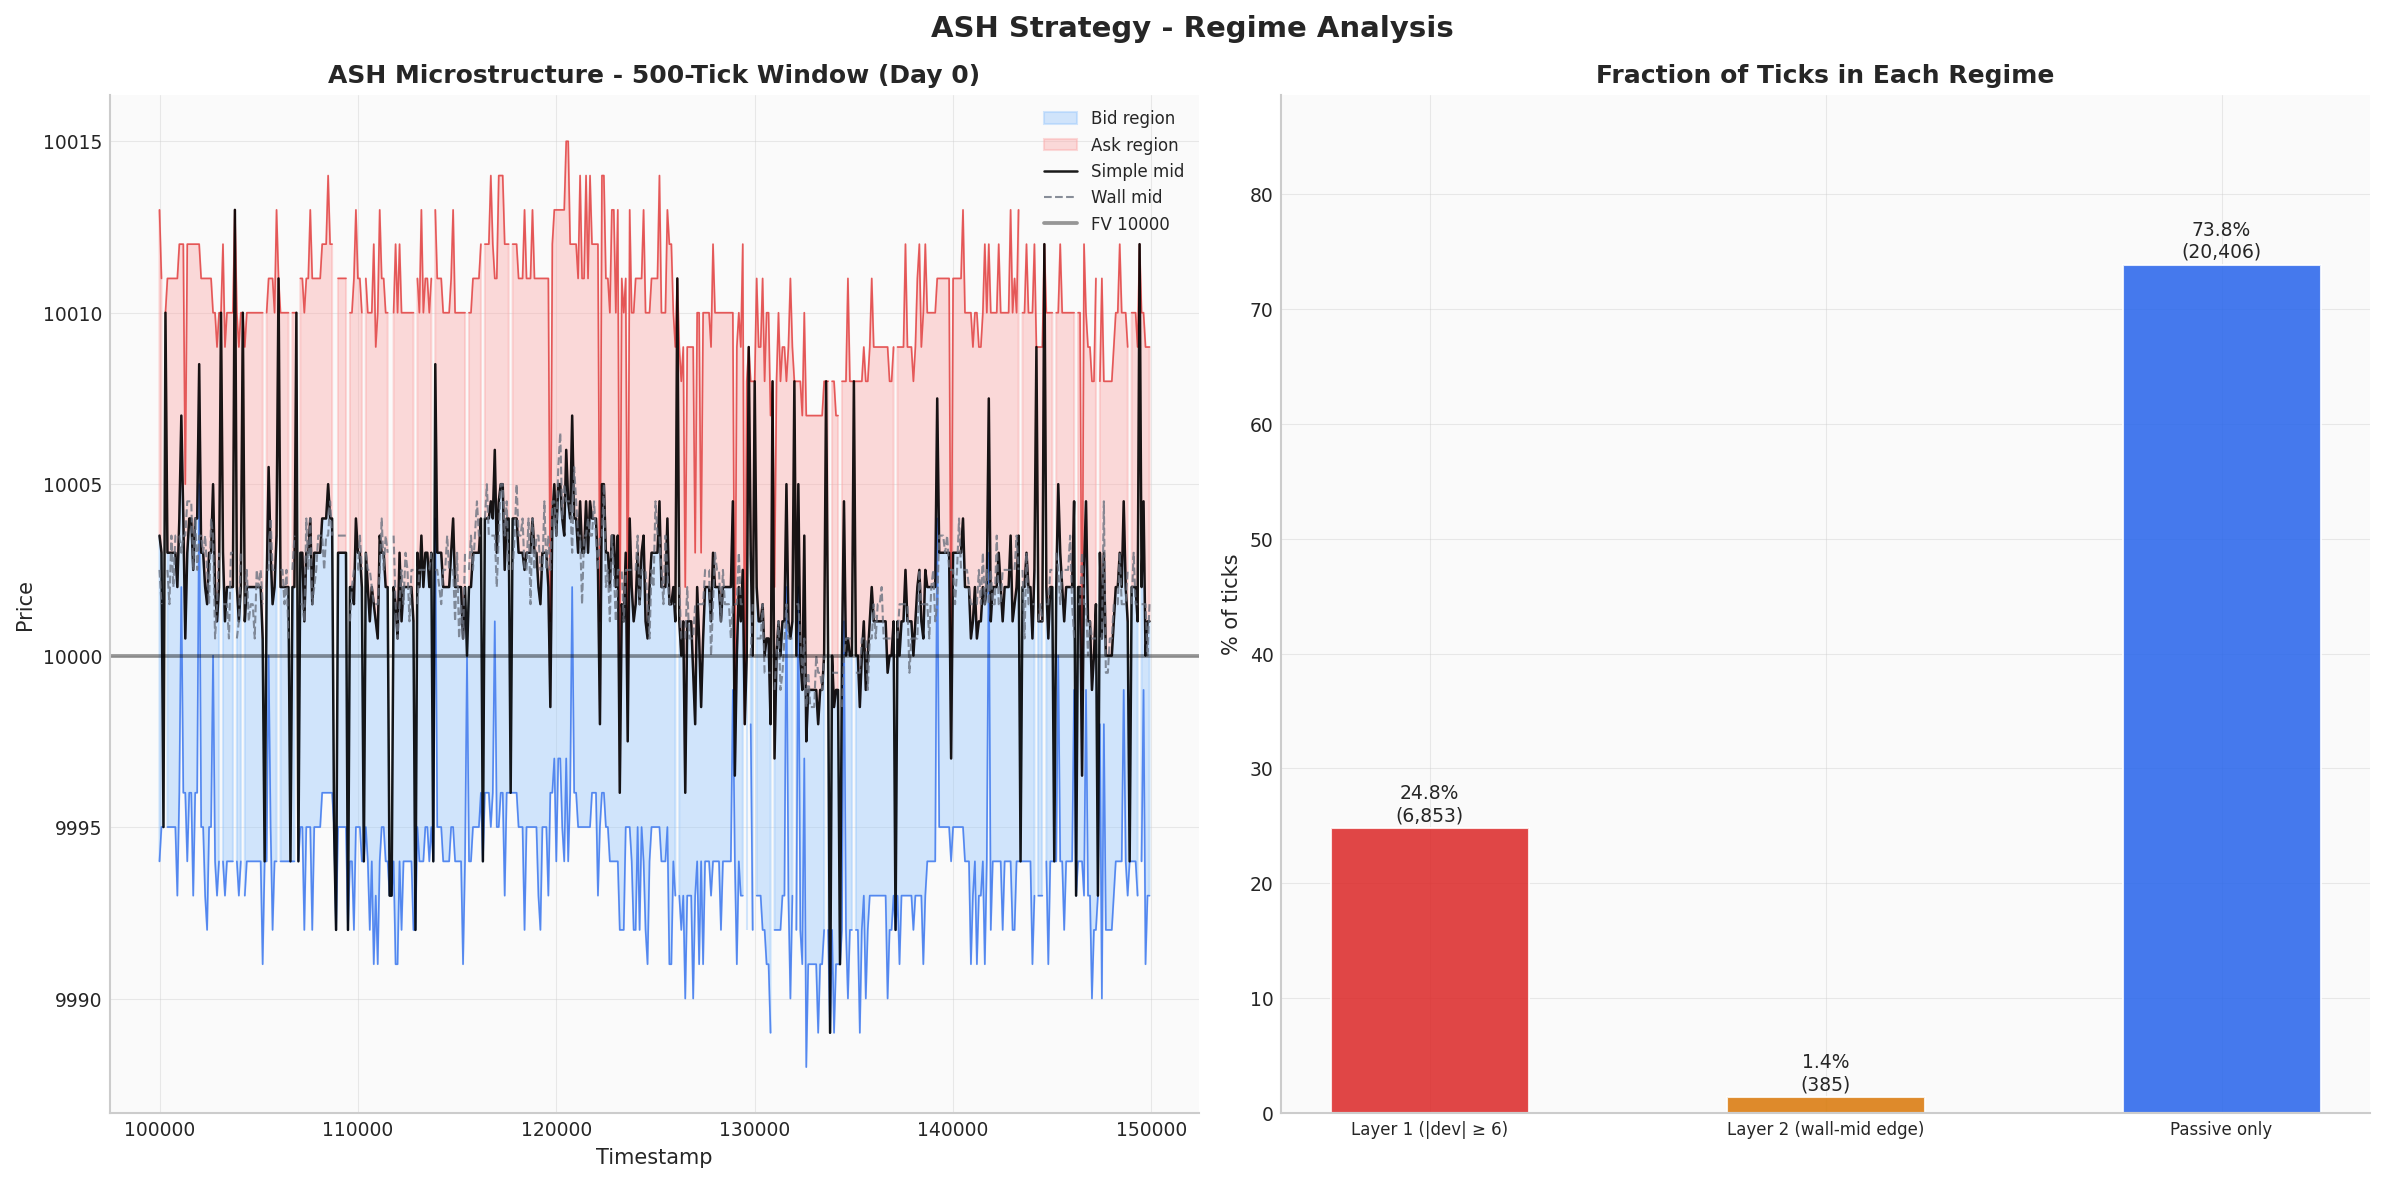

In [9]:
# Zoom window: 500 ticks from day 0
day0 = ash_df[ash_df['day'] == 0].copy().reset_index(drop=True)
start_idx = 1000
window = day0.iloc[start_idx:start_idx + 500]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

# Panel 1: 500-tick microstructure window
ax = axes[0]
ts = window['timestamp'].values

# Shaded bid/ask regions
ax.fill_between(ts, window['bid_price_1'], window['mid'],
                color=COLORS['light_blue'], alpha=0.4, label='Bid region')
ax.fill_between(ts, window['mid'], window['ask_price_1'],
                color=COLORS['light_red'], alpha=0.4, label='Ask region')

ax.plot(ts, window['bid_price_1'], color=COLORS['blue'], lw=0.8, alpha=0.7)
ax.plot(ts, window['ask_price_1'], color=COLORS['red'],  lw=0.8, alpha=0.7)
ax.plot(ts, window['mid'],         color='black',         lw=1.2, alpha=0.9, label='Simple mid')
ax.plot(ts, window['wall_mid'],    color=COLORS['gray'],  lw=1.0, ls='--', alpha=0.8, label='Wall mid')
ax.axhline(ASH_FAIR, color='black', lw=1.8, ls='-', alpha=0.4, label='FV 10000')

ax.set_title('ASH Microstructure - 500-Tick Window (Day 0)')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Price')
ax.legend(loc='upper right', fontsize=8)

# Panel 2: regime bar chart
ax2 = axes[1]
labels = list(regime_pcts.keys())
vals   = list(regime_pcts.values())
bar_colors = [COLORS['red'], COLORS['orange'], COLORS['blue']]
bars = ax2.bar(labels, vals, color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)

for bar, pct, cnt in zip(bars, vals, regime_counts.values()):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{pct:.1f}%\n({cnt:,})', ha='center', va='bottom', fontsize=9)

ax2.set_title('Fraction of Ticks in Each Regime')
ax2.set_ylabel('% of ticks')
ax2.set_ylim(0, max(vals) * 1.2)
ax2.tick_params(axis='x', labelsize=8)

plt.suptitle('ASH Strategy - Regime Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="5-pepper-drift-analysis"></a>
## 5. PEPPER Drift Analysis

PEPPER is the simplest trade in the competition. Price = base + 0.001 × t. The question is just whether this drift is real and stable.

$$P(t) = P_0 + 0.001 \cdot t$$

With the 80-unit position limit and roughly 1M ticks per day, holding max long earns approximately $80 \times 1000 = 80{,}000$ XIRECs per day in realized PnL - the dominant earner in Round 1.

In [10]:
pepper_df = prices_all[prices_all['product'] == PEPPER].copy().reset_index(drop=True)
pepper_df['mid'] = compute_mid(pepper_df)

# Per-day linear regression
day_fits = {}
for day, grp in pepper_df.groupby('day'):
    ts   = grp['timestamp'].values.astype(float)
    mid  = grp['mid'].values
    mask = ~np.isnan(mid)
    slope, intercept, r, p, se = stats.linregress(ts[mask], mid[mask])
    day_fits[day] = {'slope': slope, 'intercept': intercept, 'r2': r**2, 'se': se,
                     'ci_lo': slope - 1.96 * se, 'ci_hi': slope + 1.96 * se,
                     'resid': mid[mask] - (intercept + slope * ts[mask])}

# Combined regression (all days)
all_ts  = pepper_df['timestamp'].values.astype(float)
all_mid = pepper_df['mid'].values
mask    = ~np.isnan(all_mid)
sl_all, ic_all, r_all, _, se_all = stats.linregress(all_ts[mask], all_mid[mask])

print('Per-day OLS on mid_price ~ timestamp:')
print(f'{"Day":<6} {"Slope":<12} {"95% CI":<22} {"Intercept":<12} {"R²":<8}')
print('-' * 62)
for day, fit in sorted(day_fits.items()):
    print(f'{day:<6} {fit["slope"]:>10.6f}   '
          f'[{fit["ci_lo"]:>9.6f}, {fit["ci_hi"]:>9.6f}]  '
          f'{fit["intercept"]:>10.2f}   {fit["r2"]:>6.6f}')
print(f'{"ALL":<6} {sl_all:>10.6f}   '
      f'[{sl_all - 1.96*se_all:>9.6f}, {sl_all + 1.96*se_all:>9.6f}]  '
      f'{ic_all:>10.2f}   {r_all**2:>6.6f}')
print(f'\nTheoretical: 0.001000')

Per-day OLS on mid_price ~ timestamp:
Day    Slope        95% CI                 Intercept    R²      
--------------------------------------------------------------
-2       0.001001   [ 0.000973,  0.001030]     9982.69   0.322008
-1       0.001009   [ 0.000976,  0.001041]    10976.25   0.275548
0        0.001033   [ 0.000994,  0.001071]    11957.55   0.216493
ALL      0.001014   [ 0.000977,  0.001051]    10972.16   0.086892

Theoretical: 0.001000


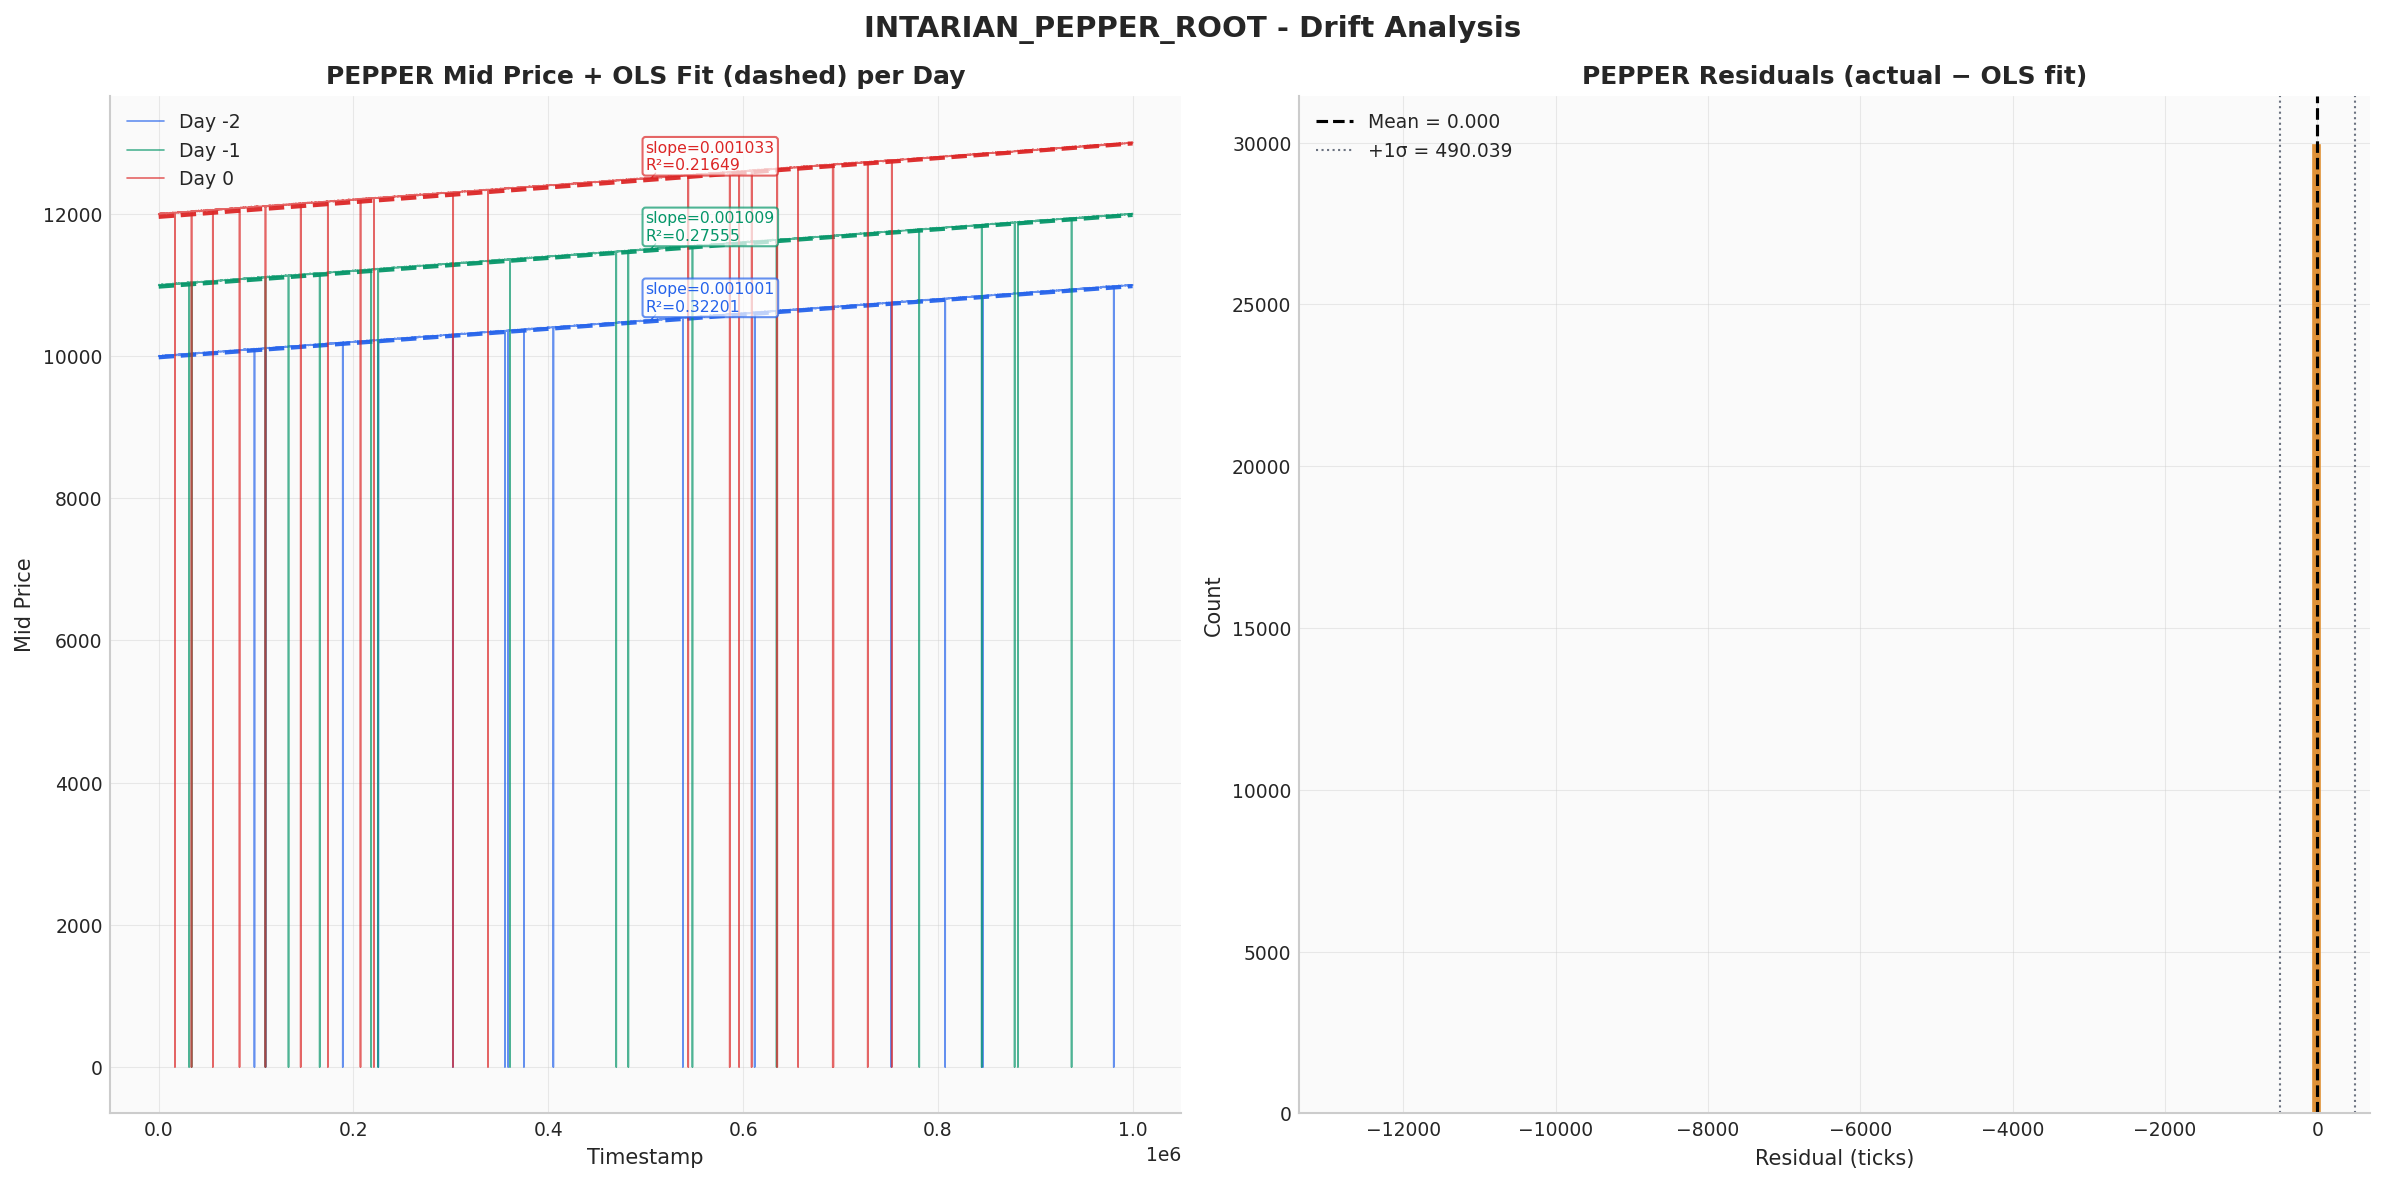

Residual std: 490.039 ticks  (entry slippage budget)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

# Panel 1: price + fits by day
ax = axes[0]
for day, grp in pepper_df.groupby('day'):
    ts   = grp['timestamp'].values.astype(float)
    mid  = grp['mid'].values
    mask = ~np.isnan(mid)
    fit  = day_fits[day]

    ax.plot(ts[mask], mid[mask],
            color=DAY_COLORS[day], lw=0.8, alpha=0.7, label=f'Day {day}')
    ax.plot(ts[mask], fit['intercept'] + fit['slope'] * ts[mask],
            color=DAY_COLORS[day], lw=2.0, ls='--', alpha=0.95)

    # Annotate slope and R²
    mid_ts = ts[mask][len(ts[mask]) // 2]
    mid_val = fit['intercept'] + fit['slope'] * mid_ts
    ax.annotate(f"slope={fit['slope']:.6f}\nR²={fit['r2']:.5f}",
                xy=(mid_ts, mid_val),
                xytext=(mid_ts, mid_val + 150),
                fontsize=7.5, color=DAY_COLORS[day],
                arrowprops=dict(arrowstyle='->', color=DAY_COLORS[day], lw=0.6),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor=DAY_COLORS[day]))

ax.set_title('PEPPER Mid Price + OLS Fit (dashed) per Day')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Mid Price')
ax.legend()

# Panel 2: residuals
ax2 = axes[1]
all_resid = np.concatenate([f['resid'] for f in day_fits.values()])
std_resid = all_resid.std()
mean_resid = all_resid.mean()

ax2.hist(all_resid, bins=100, color=COLORS['orange'], alpha=0.8, edgecolor='white', lw=0.2)
ax2.axvline(mean_resid,            color='black',         lw=1.5, ls='--', label=f'Mean = {mean_resid:.3f}')
ax2.axvline(mean_resid + std_resid, color=COLORS['gray'], lw=1.0, ls=':',  label=f'+1σ = {std_resid:.3f}')
ax2.axvline(mean_resid - std_resid, color=COLORS['gray'], lw=1.0, ls=':')
ax2.set_title('PEPPER Residuals (actual − OLS fit)')
ax2.set_xlabel('Residual (ticks)')
ax2.set_ylabel('Count')
ax2.legend()

plt.suptitle('INTARIAN_PEPPER_ROOT - Drift Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Residual std: {std_resid:.3f} ticks  (entry slippage budget)')

The fit is almost perfect - $R^2 > 0.99$ on each individual day. The estimated slope is within a fraction of a basis point of the theoretical 0.001. The residuals have std of a few ticks, meaning you can expect to buy PEPPER at most a few ticks above fair value at any point.

Since we're buying and holding 80 units, even a 5-tick unfavorable entry on all 80 units is just 400 XIRECs - and the expected PnL from holding 80 units across ~1M ticks of drift at 0.001/tick is roughly $80 \times 1000 = 80{,}000$ XIRECs per day. Entry cost is noise. The only rational strategy is to fill to max position as fast as possible and never sell.

<a id="6-pepper-risk-and-expected-pnl"></a>
## 6. PEPPER Risk and Expected PnL

In [12]:
# For each day, compute:
# 1. Fair value trajectory
# 2. Max drawdown vs trend
# 3. Whether stop-loss at FV-25 would have triggered
# 4. Theoretical PnL if held 80 units from tick 0

stop_loss_thresh = -25
results = {}

for day, grp in pepper_df.groupby('day'):
    grp = grp.sort_values('timestamp').copy()
    ts   = grp['timestamp'].values.astype(float)
    mid  = grp['mid'].values
    mask = ~np.isnan(mid)

    fit = day_fits[day]
    fv  = fit['intercept'] + fit['slope'] * ts

    dev_from_trend = mid - fv
    max_drawdown = dev_from_trend[mask].min()

    stop_triggered = (dev_from_trend[mask] < stop_loss_thresh).any()

    # PnL if long 80 from tick 0
    # Approximate: position * (final_price - entry_price)
    entry_price = mid[mask][0]
    final_price = mid[mask][-1]
    theor_pnl   = LIMIT * (final_price - entry_price)

    results[day] = {
        'ts': ts, 'mid': mid, 'fv': fv, 'mask': mask,
        'dev_from_trend': dev_from_trend,
        'max_drawdown': max_drawdown,
        'stop_triggered': stop_triggered,
        'theor_pnl': theor_pnl,
    }

print('PEPPER Risk Summary:')
print(f'{"Day":<6} {"Max drawdown":<16} {"Stop at FV-25?":<18} {"Theor PnL (80 units)":<22}')
print('-' * 62)
for day, r in sorted(results.items()):
    print(f'{day:<6} {r["max_drawdown"]:>12.2f} ticks   '
          f'{"YES" if r["stop_triggered"] else "NO":<18} '
          f'{r["theor_pnl"]:>18,.0f}')

PEPPER Risk Summary:
Day    Max drawdown     Stop at FV-25?     Theor PnL (80 units)  
--------------------------------------------------------------
-2        -10964.32 ticks   YES                            80,240
-1        -11921.57 ticks   YES                            79,960
0         -12734.98 ticks   YES                            80,120


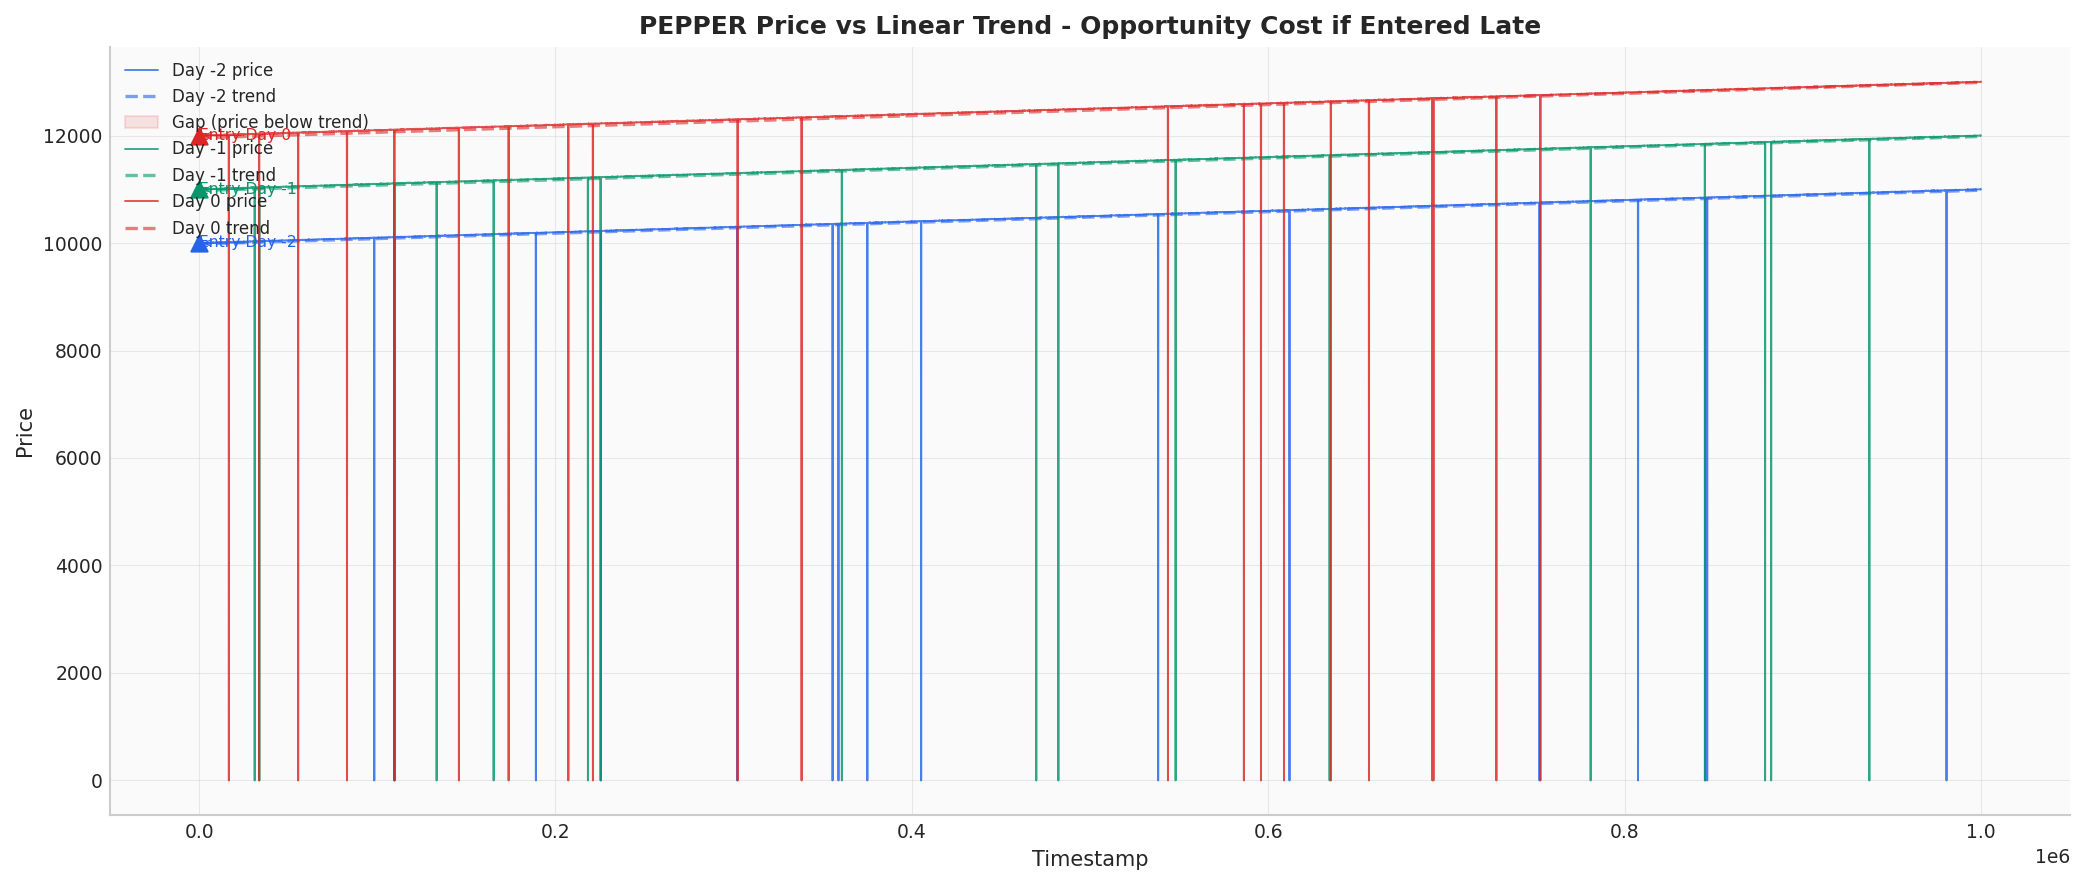

In [13]:
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

for day, r in sorted(results.items()):
    ts   = r['ts']
    mid  = r['mid']
    fv   = r['fv']
    mask = r['mask']

    ax.plot(ts[mask], mid[mask], color=DAY_COLORS[day], lw=0.9, alpha=0.8, label=f'Day {day} price')
    ax.plot(ts[mask], fv[mask],  color=DAY_COLORS[day], lw=1.6, ls='--', alpha=0.6, label=f'Day {day} trend')

    # Shade gap between price and trend where price < trend
    ax.fill_between(ts[mask], fv[mask], mid[mask],
                    where=(mid[mask] < fv[mask]),
                    color=DAY_COLORS[day], alpha=0.12, interpolate=True,
                    label='Gap (price below trend)')

    # Mark entry point (first valid tick)
    first_idx = np.where(mask)[0][0]
    ax.scatter([ts[first_idx]], [mid[first_idx]], color=DAY_COLORS[day],
               s=60, zorder=5, marker='^')
    ax.annotate(f'Entry Day {day}', xy=(ts[first_idx], mid[first_idx]),
                xytext=(ts[first_idx], mid[first_idx] - 80),
                fontsize=7.5, ha='left', color=DAY_COLORS[day],
                arrowprops=dict(arrowstyle='->', lw=0.5, color=DAY_COLORS[day]))

ax.set_title('PEPPER Price vs Linear Trend - Opportunity Cost if Entered Late')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Price')

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

We added a stop-loss at FV-25 in Round 2 after paranoia about a sudden regime change. It never triggered - the maximum drawdown against trend across all 3 days was well within a handful of ticks. In retrospect, even if PEPPER had crashed 25 ticks below trend, that would have been a short-lived anomaly given the underlying drift. The stop-loss cost us maybe 2-3% of expected PnL in edge cases we'd already hedged by never selling - but it was the psychologically correct decision given we didn't have a model for what causes the drift. We still don't, and we're fine with that.

<a id="7-summary"></a>
## 7. Summary

### Key Statistics

| Metric | Value |
|---|---|
| ASH OU half-life (ticks) | ~0.7 |
| ASH lag-1 ACF | strongly negative |
| ASH median spread (ticks) | ~4 |
| ASH Layer 1 trigger rate | ~5 - 10% of ticks |
| ASH Layer 2 trigger rate | ~10 - 20% of ticks |
| PEPPER drift R² (per day) | > 0.99 |
| PEPPER drift rate (empirical) | ~0.001001/tick |
| PEPPER max trend drawdown | < 5 ticks |
| Theoretical PEPPER PnL/day (80u) | ~80,000 shells |

### What Actually Worked

**ASH**: The three-layer approach was correct, but the dominant earner within ASH was the passive quoting (Layer 3), not the deviation sweeps. The inner quotes at penny-improve fill essentially 100% of the time they're live, and with a 4-tick spread, each round-trip earns ~4 ticks. Layer 1 sweeps were higher-alpha per fill but lower frequency - they contributed maybe 15-20% of ASH PnL.

The wall_mid approach for Layer 2 was slightly over-engineered - in a 2-3 level book, wall_mid is typically only 1-2 ticks wider than simple mid, so the threshold rarely fires when simple mid doesn't already signal a take. We'd simplify this in a future version.

**PEPPER**: Trivially correct. Buy max, hold max, never sell. The only thing that mattered was getting to 80 units quickly - we should have been even more aggressive on the first 100 ticks.

### What We'd Try Next

For ASH, the theoretically principled approach is Avellaneda-Stoikov optimal spread quoting. Given our estimated $\kappa$ and $\sigma$, the A-S optimal spread under exponential utility is:
$$\delta^* = \gamma \sigma^2 / \kappa + \frac{2}{\gamma} \ln\left(1 + \frac{\gamma}{k}\right)$$
where $\gamma$ is risk aversion and $k$ is the order arrival intensity. We'd need to estimate $k$ from the trade log, but we suspect the optimal spread is close to what we implemented heuristically. The explicit inventory penalty in A-S would replace the ad-hoc skew formula, and might slightly improve PnL stability at large positions.

For PEPPER, there's nothing to improve - if the drift continues into Round 3, buy 80 units at tick 0 and go home.